Clustering based on characteristics:
school
    MAIN - integer, flag for main campus
    PREDDEG - integer, predominant degree granting (needs encoding)
    HIGHDEG - integer, highest degree awarded (needs encoding)
    CONTROL - integer, public, private, for profit (needs encoding)
    LOCALE - integer, needs encoding
    HBCU
    PBI
    ANNHI
    TRIBAL
    AANAPII
    HSI
    NANTI
    MENONLY
    WOMENONLY
    CURROPER - integer, filter out institutions not operating anymore
academics
    PCIP01-54 - float, percent of degrees awarded in X
    PRGMOFR - integer, number of programs offered 
students 
    UGDS - integer, total enrollment of degree seeking students 
    UGDS_WHITE
    UGDS_BLACK
    UGDS_HISP
    UGDS_ASIAN
    UGDS_AIAN
    UGDS_NHPI
    UGDS_2MOR
    UGDS_NRA
    UGDS_UNKN
    UG25ABV - percent above 25
    INC_PCT_LO - percent low income
    INC_PCT_M1
    INC_PCT_M2
    INC_PCT_H1
    INC_PCT_H2
    DEP_INC_PCT_M1
    DEP_INC_PCT_M2
    DEP_INC_PCT_H1
    DEP_INC_PCT_H2
    IND_INC_PCT_M1
    IND_INC_PCT_M2
    IND_INC_PCT_H1
    IND_INC_PCT_H2
    PAR_ED_PCT_MS
    PAR_ED_PCT_HS
    PAR_ED_PCT_PS
    FEMALE
    MARRIED
    DEPENDENT
    VETERAN
    FIRST_GEN
    MEDIAN_HH_INC - median household income 
cost
    NPT4_PUB
    NPT4_PRIV
    TUITIONFEE_IN
    TUITIONFEE_OUT
    BOOKSUPPLY
    ROOMBOARD_ON
    OTHEREXPENSE_ON
    ROOMBOARD_OFF
    OTHEREXPENSE_OFF
    OTHEREXPENSE_FAM

In [2]:
import pandas as pd 

data = pd.read_csv(r"C:\Users\gabri\INST414\Most-Recent-Cohorts-Institution.csv", index_col='UNITID').fillna(0)

C:\Users\gabri\AppData\Local\Temp\ipykernel_45252\4143040912.py:3: DtypeWarning: Columns (9,1537,1540,1542,1606,1608,1614,1615,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628,1629,1690,1692,1697,1700,1725,1726,1727,1728,1729,1743,1815,1816,1817,1818,1823,1824,1830,1831,1879,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1909,1910,1911,1912,1913,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1983,1984,2376,2377,2403,2404,2495,2496,2497,2498,2499,2500,2501,2502,2503,2504,2505,2506,2507,2508,2509,2510,2511,2512,2513,2514,2515,2516,2517,2518,2519,2520,2521,2522,2523,2524,2525,2526,2527,2528,2529,2530,2958,3215,3231,3235,3236) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"C:\Users\gabri\INST414\Most-Recent-Cohorts-Institution.csv", index_col='UNITID').fillna(0)


In [3]:
#filter out institutions that are not currently operating
data = data[data['CURROPER'] == 1]

#only public or private non-profit
data = data[(data['CONTROL'] == 1) | (data['CONTROL'] == 2)]

In [4]:
##cleaning

#rename control to private where 1 is private nonprofit and 0 is public
data = data.rename(columns={'CONTROL':'PRIVATE'})
for i, r in data.iterrows():
    if r["PRIVATE"] == 1:
        data.loc[i,"PRIVATE"] = 0
    elif r["PRIVATE"] == 2:
        data.loc[i,"PRIVATE"] = 1

In [5]:
#drop columns where there is no net price listed
data = data.drop(data[(data['NPT4_PUB'] == 0) & (data['NPT4_PRIV'] == 0)].index)

In [6]:
#encode the locale
data[['CITY', 'SUBURB', 'TOWN', 'RURAL']] = 0
for i, r in data.iterrows():
    if 11 <= r["LOCALE"] <= 13:
        data.loc[i, "CITY"] = 1
    elif 21 <= r["LOCALE"] <= 23:
        data.loc[i,"SUBURB"] = 1
    elif 31 <= r["LOCALE"] <= 33:
        data.loc[i,"TOWN"] = 1
    elif 41 <= r["LOCALE"] <= 43:
        data.loc[i,"RURAL"] = 1

In [7]:
#drop locale column
data = data.drop('LOCALE', axis=1)

In [8]:
##    PREDDEG - integer, predominant degree granting (needs encoding)
#    HIGHDEG - integer, highest degree awarded (needs encoding)

#drop columns that aren't classified by highest degree or predominate degree
data = data.drop(data[(data['PREDDEG'] == 0) | (data['HIGHDEG'] == 0)].index)

data[['PREDDEG_CERT', 'PREDDEG_ASC', 'PREDDEG_BACH', 'PREDDEG_GRAD', 'HIGHDEG_CERT', 'HIGHDEG_ASC', 'HIGHDEG_BACH', 'HIGHDEG_GRAD']] = 0

#encode predominant and highest-degrees awarded
for i, r in data.iterrows():
    if r['PREDDEG'] == 1:
        data.loc[i, "PREDDEG_CERT"] = 1
    elif r["PREDDEG"] == 2:
        data.loc[i,"PREDDEG_ASC"] = 1
    elif r["PREDDEG"] == 3:
        data.loc[i,"PREDDEG_BACH"] = 1
    elif r["PREDDEG"] == 4:
        data.loc[i,"PREDDEG_GRAD"] = 1
    
    if r['HIGHDEG'] == 1:
        data.loc[i, "HIGHDEG_CERT"] = 1
    elif r['HIGHDEG'] == 2:
        data.loc[i, "HIGHDEG_ASC"] = 1
    elif r['HIGHDEG'] == 3:
        data.loc[i, "HIGHDEG_BACH"] = 1
    elif r['HIGHDEG'] == 4:
        data.loc[i, "HIGHDEG_GRAD"] = 1

In [9]:
#drop highdeg and preddeg
data = data.drop(['HIGHDEG', 'PREDDEG'], axis=1)

In [10]:
cluster_data = data[['MAIN', 'PRIVATE', 'PREDDEG_CERT', 'PREDDEG_ASC', 'PREDDEG_BACH', 'PREDDEG_GRAD', 'HIGHDEG_CERT', 'HIGHDEG_ASC', 'HIGHDEG_BACH', 'HIGHDEG_GRAD', 'CITY', 'SUBURB', 'TOWN', 'RURAL', 'HBCU', 'PBI', 'ANNHI', 'TRIBAL', 'HSI', 'NANTI', 'MENONLY', 'WOMENONLY', 'PCIP01', 'PCIP03', 'PCIP04', 'PCIP05', 'PCIP09', 'PCIP10', 'PCIP11', 'PCIP12', 'PCIP13', 'PCIP14', 'PCIP15', 'PCIP16', 'PCIP19', 'PCIP22', 'PCIP23', 'PCIP24', 'PCIP25', 'PCIP26', 'PCIP27', 'PCIP29', 'PCIP30', 'PCIP31', 'PCIP38', 'PCIP39', 'PCIP40', 'PCIP41', 'PCIP42', 'PCIP43', 'PCIP44', 'PCIP45', 'PCIP46', 'PCIP47', 'PCIP48', 'PCIP49', 'PCIP50', 'PCIP51', 'PCIP52', 'PCIP54', 'PRGMOFR', 'UGDS', 'UGDS_WHITE', 'UGDS_BLACK', 'UGDS_HISP', 'UGDS_ASIAN', 'UGDS_AIAN', 'UGDS_NHPI', 'UGDS_2MOR', 'UGDS_NRA', 'UGDS_UNKN', 'UG25ABV', 'INC_PCT_LO', 'INC_PCT_M1', 'INC_PCT_M2', 'INC_PCT_H1', 'INC_PCT_H2', 'DEP_INC_PCT_M1', 'DEP_INC_PCT_M2', 'DEP_INC_PCT_H1', 'DEP_INC_PCT_H2', 'IND_INC_PCT_M1', 'IND_INC_PCT_M2', 'IND_INC_PCT_H1', 'IND_INC_PCT_H2', 'PAR_ED_PCT_MS', 'PAR_ED_PCT_HS', 'PAR_ED_PCT_PS', 'FEMALE', 'MARRIED', 'DEPENDENT', 'VETERAN', 'FIRST_GEN', 'MEDIAN_HH_INC', 'NPT4_PUB', 'NPT4_PRIV', 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'BOOKSUPPLY', 'ROOMBOARD_ON', 'OTHEREXPENSE_ON', 'ROOMBOARD_OFF', 'OTHEREXPENSE_OFF', 'OTHEREXPENSE_FAM']]

In [11]:
#what is this?????
cluster_data.replace("PS", 0, inplace=True)

C:\Users\gabri\AppData\Local\Temp\ipykernel_45252\1705540158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data.replace("PS", 0, inplace=True)


In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 

inertia_values = []
for k in range(2,31):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_data)
    inertia_values.append(kmeans.inertia_)

In [13]:
prev = inertia_values[0]
for inertia in inertia_values[1:]:
    print(prev-inertia)
    prev=inertia

644768040702.4402
243951332606.60815
265624723172.47583
91600800763.01904
98174941295.5929
35515000373.438965
49259217425.85901
52196146112.232666
26355319779.215088
29960110212.383057
16221634660.98291
17311884080.271484
23554027059.385437
10165050497.238342
10678178203.917725
19511050080.97766
11036496352.841003
-1138576533.897583
6585196949.633362
14260712847.630371
22907206215.690918
7239630323.044312
9463291215.772217
9905666647.109192
12557850762.070496
6787399106.572388
9624880632.495544
5507848272.572571


<function matplotlib.pyplot.show(close=None, block=None)>

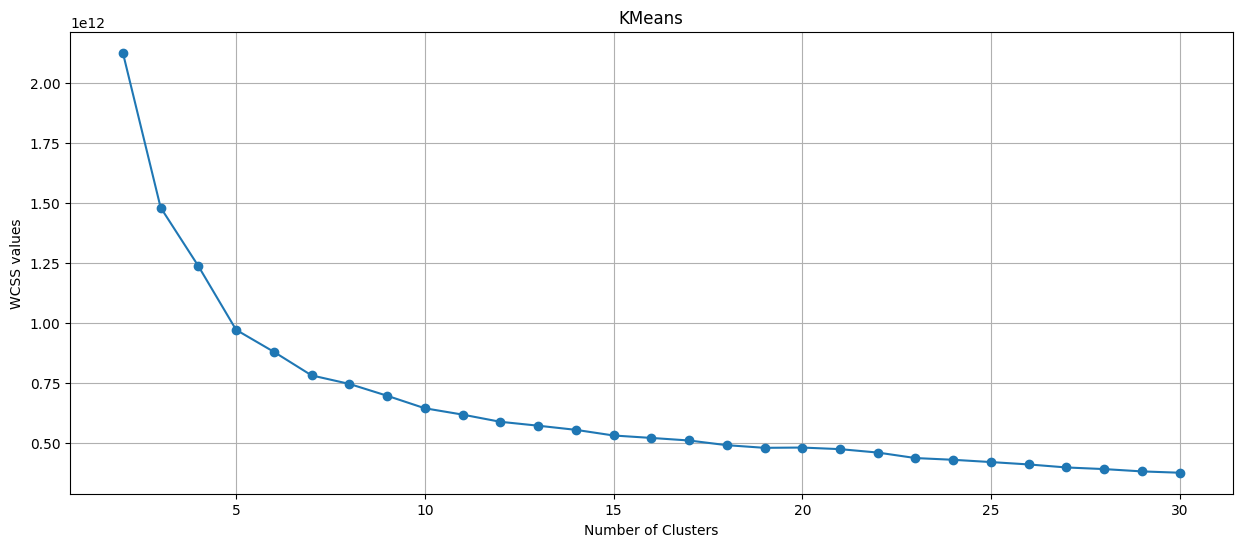

In [14]:
plt.figure(figsize=(15,6))
plt.title("KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS values")
plt.plot(range(2,31), inertia_values,marker='o')
plt.grid(True)
plt.show

In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(cluster_data)
cluster_data['clusters'] = cluster_labels
grouped = cluster_data.groupby('clusters')

print(f"Number of crimes per cluster: {cluster_data['clusters'].value_counts()}")

Number of crimes per cluster: clusters
4    1110
2     600
5     448
0     408
1     364
3     252
Name: count, dtype: int64


C:\Users\gabri\AppData\Local\Temp\ipykernel_45252\1347529630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['clusters'] = cluster_labels


In [16]:
data['clusters'] = cluster_labels
data

,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,SCH_DEG,...,RURAL,PREDDEG_CERT,PREDDEG_ASC,PREDDEG_BACH,PREDDEG_GRAD,HIGHDEG_CERT,HIGHDEG_ASC,HIGHDEG_BACH,HIGHDEG_GRAD,clusters
UNITID,,,,,,,,,,,,,,,,,,,,,
100654,100200.0,1002.0,Alabama A & M University,1,AL,35762,Southern Association of Colleges and Schools C...,www.aamu.edu/,www.aamu.edu/admissions-aid/tuition-fees/net-p...,3.0,...,0,0,0,1,0,0,0,0,1,4
100663,105200.0,1052.0,University of Alabama at Birmingham,1,AL,35294-0110,Southern Association of Colleges and Schools C...,https://www.uab.edu/,https://tcc.ruffalonl.com/University of Alabam...,3.0,...,0,0,0,1,0,0,0,0,1,0
100706,105500.0,1055.0,University of Alabama in Huntsville,1,AL,35899,Southern Association of Colleges and Schools C...,www.uah.edu/,finaid.uah.edu/,3.0,...,0,0,0,1,0,0,0,0,1,0
100724,100500.0,1005.0,Alabama State University,1,AL,36104-0271,Southern Association of Colleges and Schools C...,www.alasu.edu/,www.alasu.edu/cost-aid/tuition-costs/net-price...,3.0,...,0,0,0,1,0,0,0,0,1,4
100751,105100.0,1051.0,The University of Alabama,1,AL,35487-0100,Southern Association of Colleges and Schools C...,www.ua.edu/,ua.aidcalc.cloud/netprice.htm,3.0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497824,246300.0,2463.0,Evangel University-College of Online Learning,1,MO,65802-2125,Higher Learning Commission,https://www.evangel.edu/,https://www.evangel.edu/tuition-fees-and-billing/,0.0,...,0,0,0,1,0,0,0,1,0,5
497833,182103.0,1821.0,Marian University-Ancilla,0,IN,46563-9475,Higher Learning Commission,https://www.marian.edu/ancilla,https://www.marian.edu/ancilla/admissions,0.0,...,1,0,1,0,0,0,1,0,0,2
498012,2241911.0,22419.0,Commonwealth of Puerto Rico Department of Educ...,0,PR,00738-0000,Puerto Rico State Agency for the Approval of P...,https://prami-fajardo.wixsite.com/admin,https://de.pr.gov/aea/prami/,0.0,...,0,1,0,0,0,1,0,0,0,3


In [17]:
for cluster_id, group in data.groupby('clusters'):
    print(f"Cluster {cluster_id}")
    print(group['INSTNM'])

Cluster 0
UNITID
100663        University of Alabama at Birmingham
100706        University of Alabama in Huntsville
100751                  The University of Alabama
100858                          Auburn University
101480              Jacksonville State University
                           ...                   
482680                University of North Georgia
486840                  Kennesaw State University
489779                   Purdue University Global
498562    Commonwealth University of Pennsylvania
498571            Pennsylvania Western University
Name: INSTNM, Length: 408, dtype: object
Cluster 1
UNITID
104586    Embry-Riddle Aeronautical University-Prescott
108852    American Academy of Dramatic Arts-Los Angeles
109651                     Art Center College of Design
109785                         Azusa Pacific University
110097                                 Biola University
                              ...                      
239716                            Saint

In [18]:
#add here code that ranks schools in each cluster 

identify metrics to measure and compare on
earnings
COUNT_NWNE_P6
COUNT_WNE_P6
MD_EARN_WNE_P6
PCT25_EARN_WNE_P6
PCT75_EARN_WNE_P6
COUNT_WNE_INC1_P6
COUNT_WNE_INC2_P6
COUNT_WNE_INC3_P6
COUNT_WNE_INDEP0_P6
COUNT_WNE_INDEP1_P6
COUNT_WNE_MALE0_P6
COUNT_WNE_MALE1_P6
GT_THRESHOLD_P6
MD_EARN_WNE_INC1_P6
MD_EARN_WNE_INC2_P6
MD_EARN_WNE_INC3_P6
MD_EARN_WNE_INDEP1_P6
MD_EARN_WNE_INDEP0_P6
MD_EARN_WNE_MALE0_P6
MD_EARN_WNE_MALE1_P6
COUNT_NWNE_P10
COUNT_WNE_P10
MD_EARN_WNE_P10
PCT25_EARN_WNE_P10
PCT75_EARN_WNE_P10
COUNT_WNE_INC1_P10
COUNT_WNE_INC2_P10
COUNT_WNE_INC3_P10
COUNT_WNE_INDEP0_P10
COUNT_WNE_INDEP1_P10
COUNT_WNE_MALE0_P10
COUNT_WNE_MALE1_P10
GT_THRESHOLD_P10
MD_EARN_WNE_INC1_P10
MD_EARN_WNE_INC2_P10
MD_EARN_WNE_INC3_P10
MD_EARN_WNE_INDEP1_P10
MD_EARN_WNE_INDEP0_P10
MD_EARN_WNE_MALE0_P10
MD_EARN_WNE_MALE1_P10

compeltion
DEATH_YR4_RT
COMP_ORIG_YR4_RT
COMP_4YR_TRANS_YR4_RT
COMP_2YR_TRANS_YR4_RT
WDRAW_ORIG_YR4_RT
WDRAW_4YR_TRANS_YR4_RT
WDRAW_2YR_TRANS_YR4_RT
ENRL_ORIG_YR4_RT
ENRL_4YR_TRANS_YR4_RT
ENRL_2YR_TRANS_YR4_RT
UNKN_ORIG_YR4_RT
UNKN_4YR_TRANS_YR4_RT
UNKN_2YR_TRANS_YR4_RT
DEATH_YR6_RT
COMP_ORIG_YR6_RT
COMP_4YR_TRANS_YR6_RT
COMP_2YR_TRANS_YR6_RT
WDRAW_ORIG_YR6_RT
WDRAW_4YR_TRANS_YR6_RT
WDRAW_2YR_TRANS_YR6_RT
ENRL_ORIG_YR6_RT
ENRL_4YR_TRANS_YR6_RT
ENRL_2YR_TRANS_YR6_RT
UNKN_ORIG_YR6_RT
UNKN_4YR_TRANS_YR6_RT
UNKN_2YR_TRANS_YR6_RT

debt
DEBT_MDN
GRAD_DEBT_MDN
WDRAW_DEBT_MDN
LO_INC_DEBT_MDN
MD_INC_DEBT_MDN
HI_INC_DEBT_MDN
DEP_DEBT_MDN
IND_DEBT_MDN
PELL_DEBT_MDN
NOPELL_DEBT_MDN
FEMALE_DEBT_MDN
MALE_DEBT_MDN
FIRSTGEN_DEBT_MDN
NOTFIRSTGEN_DEBT_MDN

admissions
ADM_RATE

cost
    NPT4_PUB
    NPT4_PRIV
    TUITIONFEE_IN
    TUITIONFEE_OUT
    BOOKSUPPLY
    ROOMBOARD_ON
    OTHEREXPENSE_ON
    ROOMBOARD_OFF
    OTHEREXPENSE_OFF
    OTHEREXPENSE_FAM

In [19]:
compare_data = data[['COUNT_NWNE_P6', 'COUNT_WNE_P6', "MD_EARN_WNE_P6",
"PCT25_EARN_WNE_P6",
"PCT75_EARN_WNE_P6",
"COUNT_WNE_INC1_P6",
"COUNT_WNE_INC2_P6",
"COUNT_WNE_INC3_P6",
"COUNT_WNE_INDEP0_P6",
"COUNT_WNE_INDEP1_P6",
"COUNT_WNE_MALE0_P6",
"COUNT_WNE_MALE1_P6",
"GT_THRESHOLD_P6",
"MD_EARN_WNE_INC1_P6",
"MD_EARN_WNE_INC2_P6",
"MD_EARN_WNE_INC3_P6",
"MD_EARN_WNE_INDEP1_P6",
"MD_EARN_WNE_INDEP0_P6",
"MD_EARN_WNE_MALE0_P6",
"MD_EARN_WNE_MALE1_P6",
"COUNT_NWNE_P10",
"COUNT_WNE_P10",
"MD_EARN_WNE_P10",
"PCT25_EARN_WNE_P10",
"PCT75_EARN_WNE_P10",
"COUNT_WNE_INC1_P10",
"COUNT_WNE_INC2_P10",
"COUNT_WNE_INC3_P10",
"COUNT_WNE_INDEP0_P10",
"COUNT_WNE_INDEP1_P10",
"COUNT_WNE_MALE0_P10",
"COUNT_WNE_MALE1_P10",
"GT_THRESHOLD_P10",
"MD_EARN_WNE_INC1_P10",
"MD_EARN_WNE_INC2_P10",
"MD_EARN_WNE_INC3_P10",
"MD_EARN_WNE_INDEP1_P10",
"MD_EARN_WNE_INDEP0_P10",
"MD_EARN_WNE_MALE0_P10",
"MD_EARN_WNE_MALE1_P10",
"DEATH_YR4_RT",
"COMP_ORIG_YR4_RT",
"COMP_4YR_TRANS_YR4_RT",
"COMP_2YR_TRANS_YR4_RT",
"WDRAW_ORIG_YR4_RT",
"WDRAW_4YR_TRANS_YR4_RT",
"WDRAW_2YR_TRANS_YR4_RT",
"ENRL_ORIG_YR4_RT",
"ENRL_4YR_TRANS_YR4_RT",
"ENRL_2YR_TRANS_YR4_RT",
"UNKN_ORIG_YR4_RT",
"UNKN_4YR_TRANS_YR4_RT",
"UNKN_2YR_TRANS_YR4_RT",
"DEATH_YR6_RT",
"COMP_ORIG_YR6_RT",
"COMP_4YR_TRANS_YR6_RT",
"COMP_2YR_TRANS_YR6_RT",
"WDRAW_ORIG_YR6_RT",
"WDRAW_4YR_TRANS_YR6_RT",
"WDRAW_2YR_TRANS_YR6_RT",
"ENRL_ORIG_YR6_RT",
"ENRL_4YR_TRANS_YR6_RT",
"ENRL_2YR_TRANS_YR6_RT",
"UNKN_ORIG_YR6_RT",
"UNKN_4YR_TRANS_YR6_RT",
"UNKN_2YR_TRANS_YR6_RT",
"DEBT_MDN",
"GRAD_DEBT_MDN",
"WDRAW_DEBT_MDN",
"LO_INC_DEBT_MDN",
"MD_INC_DEBT_MDN",
"HI_INC_DEBT_MDN",
"DEP_DEBT_MDN",
"IND_DEBT_MDN",
"PELL_DEBT_MDN",
"NOPELL_DEBT_MDN",
"FEMALE_DEBT_MDN",
"MALE_DEBT_MDN",
"FIRSTGEN_DEBT_MDN",
"NOTFIRSTGEN_DEBT_MDN",
"NPT4_PUB",
"NPT4_PRIV",
"TUITIONFEE_IN",
"TUITIONFEE_OUT",
"BOOKSUPPLY",
"ROOMBOARD_ON",
"OTHEREXPENSE_ON",
"ROOMBOARD_OFF",
"OTHEREXPENSE_OFF",
"OTHEREXPENSE_FAM"]]

compare_data.replace("PS", 0, inplace=True)

C:\Users\gabri\AppData\Local\Temp\ipykernel_45252\1832810920.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_data.replace("PS", 0, inplace=True)


In [20]:
from sklearn.preprocessing import StandardScaler

#normalize data
scaler = StandardScaler()

compare_data_scaled = scaler.fit_transform(compare_data)
scaled_data = pd.DataFrame(compare_data_scaled,
                                       index=compare_data.index,
                                       columns=compare_data.columns)


In [21]:
#add cluster assignments
compare_data['cluster'] = cluster_labels
compare_data

C:\Users\gabri\AppData\Local\Temp\ipykernel_45252\1626949101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_data['cluster'] = cluster_labels


,COUNT_NWNE_P6,COUNT_WNE_P6,MD_EARN_WNE_P6,PCT25_EARN_WNE_P6,PCT75_EARN_WNE_P6,COUNT_WNE_INC1_P6,COUNT_WNE_INC2_P6,COUNT_WNE_INC3_P6,COUNT_WNE_INDEP0_P6,COUNT_WNE_INDEP1_P6,...,NPT4_PRIV,TUITIONFEE_IN,TUITIONFEE_OUT,BOOKSUPPLY,ROOMBOARD_ON,OTHEREXPENSE_ON,ROOMBOARD_OFF,OTHEREXPENSE_OFF,OTHEREXPENSE_FAM,cluster
UNITID,,,,,,,,,,,,,,,,,,,,,
100654,163.0,1539.0,27851.0,14130.0,44543.0,1013.0,382.0,144.0,1315.0,224.0,...,0.0,10024.0,18634.0,1600.0,9520.0,3090.0,9520.0,3090.0,3440.0,4
100663,327.0,3250.0,46572.0,29464.0,66959.0,1431.0,972.0,848.0,2139.0,1111.0,...,0.0,8832.0,21216.0,1200.0,13120.0,5757.0,14330.0,6007.0,6007.0,0
100706,160.0,1468.0,55610.0,33999.0,81066.0,610.0,424.0,436.0,960.0,509.0,...,0.0,11878.0,24770.0,2416.0,11122.0,4462.0,11122.0,4462.0,4462.0,0
100724,175.0,1773.0,27453.0,15271.0,40900.0,1181.0,446.0,145.0,1513.0,256.0,...,0.0,11068.0,19396.0,1600.0,6050.0,3392.0,7320.0,5130.0,5130.0,4
100751,696.0,6231.0,52233.0,33353.0,75004.0,1665.0,1634.0,2928.0,5314.0,918.0,...,0.0,11940.0,32300.0,800.0,14426.0,4858.0,14426.0,4858.0,6028.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497824,103.0,898.0,39332.0,25411.0,52047.0,268.0,364.0,265.0,700.0,197.0,...,22221.0,8025.0,8025.0,966.0,0.0,0.0,11512.0,5451.0,400.0,5
497833,62.0,913.0,55704.0,38379.0,77814.0,306.0,296.0,311.0,531.0,382.0,...,20104.0,19850.0,19850.0,0.0,10400.0,8318.0,10194.0,8318.0,6229.0,2
498012,750.0,991.0,22824.0,9045.0,37672.0,0.0,0.0,0.0,729.0,265.0,...,0.0,3800.0,3800.0,900.0,0.0,0.0,5000.0,4000.0,4800.0,3


In [22]:
from scipy.sparse import lil_matrix
import scipy.spatial.distance

#target school = UMD
target_school_id = 163286
target_cluster = compare_data.loc[target_school_id, 'cluster']

#ensure data is in the same cluster (thanks chatgpt)
cluster_mask = compare_data['cluster'] == target_cluster
compare_data_same_cluster = compare_data[cluster_mask]
scaled_data_same_cluster = scaled_data.loc[cluster_mask]

#transform to 2d array
target_school_scaled = scaled_data_same_cluster.loc[[target_school_id]].values

distances = scipy.spatial.distance.cdist(scaled_data_same_cluster.values, target_school_scaled, metric='euclidean').flatten()
query_distances = list(zip(scaled_data_same_cluster.index, distances))

for similar_school_id, similar_score in sorted(query_distances, key=lambda x:x[1], reverse=False)[:11]:
    school_info = data.loc[similar_school_id]
    cluster = school_info['clusters']
    name = school_info["INSTNM"]
    print(f"{similar_school_id} | Cluster: {cluster} | {name} | Distance: {similar_score:.4f}")

163286 | Cluster: 0 | University of Maryland-College Park | Distance: 0.0000
233921 | Cluster: 0 | Virginia Polytechnic Institute and State University | Distance: 2.3521
240444 | Cluster: 0 | University of Wisconsin-Madison | Distance: 2.7577
199193 | Cluster: 0 | North Carolina State University at Raleigh | Distance: 3.5749
170976 | Cluster: 0 | University of Michigan-Ann Arbor | Distance: 3.6612
232186 | Cluster: 0 | George Mason University | Distance: 3.6639
110422 | Cluster: 0 | California Polytechnic State University-San Luis Obispo | Distance: 3.6804
139959 | Cluster: 0 | University of Georgia | Distance: 3.7882
243780 | Cluster: 0 | Purdue University-Main Campus | Distance: 3.8878
228778 | Cluster: 0 | The University of Texas at Austin | Distance: 3.9932
232423 | Cluster: 0 | James Madison University | Distance: 4.1484


In [23]:
#target school = Yale
target_school_id = 130794
target_cluster = compare_data.loc[target_school_id, 'cluster']

#ensure data is in the same cluster (thanks chatgpt)
cluster_mask = compare_data['cluster'] == target_cluster
compare_data_same_cluster = compare_data[cluster_mask]
scaled_data_same_cluster = scaled_data.loc[cluster_mask]

#transform to 2d array
target_school_scaled = scaled_data_same_cluster.loc[[target_school_id]].values

distances = scipy.spatial.distance.cdist(scaled_data_same_cluster.values, target_school_scaled, metric='euclidean').flatten()
query_distances = list(zip(scaled_data_same_cluster.index, distances))

for similar_school_id, similar_score in sorted(query_distances, key=lambda x:x[1], reverse=False)[:11]:
    school_info = data.loc[similar_school_id]
    cluster = school_info['clusters']
    name = school_info["INSTNM"]
    print(f"{similar_school_id} | Cluster: {cluster} | {name} | Distance: {similar_score:.4f}")

130794 | Cluster: 1 | Yale University | Distance: 0.0000
198419 | Cluster: 1 | Duke University | Distance: 2.9096
131496 | Cluster: 1 | Georgetown University | Distance: 3.3749
221999 | Cluster: 1 | Vanderbilt University | Distance: 4.3946
166027 | Cluster: 1 | Harvard University | Distance: 4.7262
162928 | Cluster: 1 | Johns Hopkins University | Distance: 5.0272
190415 | Cluster: 1 | Cornell University | Distance: 5.3920
243744 | Cluster: 1 | Stanford University | Distance: 5.5322
215062 | Cluster: 1 | University of Pennsylvania | Distance: 5.7017
147767 | Cluster: 1 | Northwestern University | Distance: 6.4412
179867 | Cluster: 1 | Washington University in St Louis | Distance: 6.5837


In [24]:
#target school = Hood College, same cluster as last, seeing different results than first time I did this as well
target_school_id = 162760
target_cluster = compare_data.loc[target_school_id, 'cluster']

#ensure data is in the same cluster (thanks chatgpt)
cluster_mask = compare_data['cluster'] == target_cluster
compare_data_same_cluster = compare_data[cluster_mask]
scaled_data_same_cluster = scaled_data.loc[cluster_mask]

#transform to 2d array
target_school_scaled = scaled_data_same_cluster.loc[[target_school_id]].values

distances = scipy.spatial.distance.cdist(scaled_data_same_cluster.values, target_school_scaled, metric='euclidean').flatten()
query_distances = list(zip(scaled_data_same_cluster.index, distances))

for similar_school_id, similar_score in sorted(query_distances, key=lambda x:x[1], reverse=False)[:11]:
    school_info = data.loc[similar_school_id]
    cluster = school_info['clusters']
    name = school_info["INSTNM"]
    print(f"{similar_school_id} | Cluster: {cluster} | {name} | Distance: {similar_score:.4f}")

162760 | Cluster: 1 | Hood College | Distance: 0.0000
228343 | Cluster: 1 | Southwestern University | Distance: 3.0664
153144 | Cluster: 1 | Coe College | Distance: 3.1057
227845 | Cluster: 1 | Saint Edward's University | Distance: 3.1087
144962 | Cluster: 1 | Elmhurst University | Distance: 3.1859
164270 | Cluster: 1 | McDaniel College | Distance: 3.2841
184348 | Cluster: 1 | Drew University | Distance: 3.4226
211981 | Cluster: 1 | Delaware Valley University | Distance: 3.4681
236230 | Cluster: 1 | Pacific Lutheran University | Distance: 3.4704
209612 | Cluster: 1 | Pacific University | Distance: 3.4830
210401 | Cluster: 1 | Willamette University | Distance: 3.5057


In [25]:
#target school = FCC
target_school_id = 162557
target_cluster = compare_data.loc[target_school_id, 'cluster']

#ensure data is in the same cluster (thanks chatgpt)
cluster_mask = compare_data['cluster'] == target_cluster
compare_data_same_cluster = compare_data[cluster_mask]
scaled_data_same_cluster = scaled_data.loc[cluster_mask]

#transform to 2d array
target_school_scaled = scaled_data_same_cluster.loc[[target_school_id]].values

distances = scipy.spatial.distance.cdist(scaled_data_same_cluster.values, target_school_scaled, metric='euclidean').flatten()
query_distances = list(zip(scaled_data_same_cluster.index, distances))

for similar_school_id, similar_score in sorted(query_distances, key=lambda x:x[1], reverse=False)[:11]:
    school_info = data.loc[similar_school_id]
    cluster = school_info['clusters']
    name = school_info["INSTNM"]
    print(f"{similar_school_id} | Cluster: {cluster} | {name} | Distance: {similar_score:.4f}")

162557 | Cluster: 5 | Frederick Community College | Distance: 0.0000
232195 | Cluster: 5 | Germanna Community College | Distance: 2.5450
147004 | Cluster: 5 | McHenry County College | Distance: 2.6681
186645 | Cluster: 5 | Raritan Valley Community College | Distance: 2.8375
232575 | Cluster: 5 | Laurel Ridge Community College | Distance: 2.9833
141796 | Cluster: 5 | Kapiolani Community College | Distance: 2.9990
162122 | Cluster: 5 | College of Southern Maryland | Distance: 3.0134
141811 | Cluster: 5 | Leeward Community College | Distance: 3.0342
126711 | Cluster: 5 | Colorado Mountain College | Distance: 3.0576
384342 | Cluster: 5 | Heartland Community College | Distance: 3.0686
233116 | Cluster: 5 | Piedmont Virginia Community College | Distance: 3.0894
